# Exploratory Data Analysis
**Goal:** Get a first understanding of the Petfinder dataset before modeling.

Target variable: `AdoptionSpeed`

0 - Pet was adopted on the same day as it was listed.

1 - Pet was adopted between 1 and 7 days (1st week) after being listed.

2 - Pet was adopted between 8 and 30 days (1st month) after being listed.

3 - Pet was adopted between 31 and 90 days (2nd & 3rd month) after being listed.

4 - No adoption after 100 days of being listed. (There are no pets in this dataset that waited between 90 and 100 days).

## 1. Setup & Data Loading

In [50]:
import sys, os, json
from pathlib import Path

os.chdir(r'C:\Users\norap\AdoptSense-Pet-Adoption-Prediction')
sys.path.append(os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import Config

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

cfg = Config()
df            = pd.read_csv(cfg.TRAIN_CSV)
breed_labels  = pd.read_csv(cfg.BREED_LABELS)
color_labels  = pd.read_csv(cfg.COLOR_LABELS)
state_labels  = pd.read_csv(cfg.STATE_LABELS)

# --- Label mappings ---
speed_labels  = {0: 'Same day', 1: '1-7d', 2: '8-30d', 3: '31-90d', 4: 'No adoption'}
color_map     = color_labels.set_index('ColorID')['ColorName'].to_dict()
state_map     = state_labels.set_index('StateID')['StateName'].to_dict()

df['AdoptionSpeed_label']  = df['AdoptionSpeed'].map(speed_labels)
df['Type_label']           = df['Type'].map({1: 'Dog', 2: 'Cat'})
df['Gender_label']         = df['Gender'].map({1: 'Male', 2: 'Female', 3: 'Mixed'})
df['MaturitySize_label']   = df['MaturitySize'].map({0: 'N/A', 1: 'Small', 2: 'Medium', 3: 'Large', 4: 'Extra Large'})
df['FurLength_label']      = df['FurLength'].map({0: 'N/A', 1: 'Short', 2: 'Medium', 3: 'Long'})
df['Vaccinated_label']     = df['Vaccinated'].map({1: 'Yes', 2: 'No', 3: 'Not Sure'})
df['Dewormed_label']       = df['Dewormed'].map({1: 'Yes', 2: 'No', 3: 'Not Sure'})
df['Sterilized_label']     = df['Sterilized'].map({1: 'Yes', 2: 'No', 3: 'Not Sure'})
df['Health_label']         = df['Health'].map({1: 'Healthy', 2: 'Minor Injury', 3: 'Serious Injury'})
df['Color1_label']         = df['Color1'].map(color_map)
df['State_label']          = df['State'].map(state_map)

# --- Derived features ---
df['age_bin']         = pd.cut(df['Age'], bins=[-1,1,3,12,24,300],
                                labels=['<1mo','1-3mo','3-12mo','1-2yr','2yr+'])
df['desc_len']        = df['Description'].fillna('').apply(len)
df['desc_word_count'] = df['Description'].fillna('').apply(lambda x: len(x.split()))
df['has_name']        = df['Name'].notna().map({True: 'Has Name', False: 'No Name'})
df['has_photo']       = (df['PhotoAmt'] > 0).map({True: 'Yes', False: 'No'})
df['has_video']       = (df['VideoAmt'] > 0).map({True: 'Yes', False: 'No'})
df['is_free']         = (df['Fee'] == 0).map({True: 'Free', False: 'Paid'})
df['photo_bin']       = pd.cut(df['PhotoAmt'], bins=[-1,0,2,5,10,100],
                                labels=['0','1-2','3-5','6-10','10+'])
df['desc_bin']        = pd.cut(df['desc_word_count'], bins=[-1,0,25,75,150,1000],
                                labels=['None','Short','Medium','Long','Very Long'])

print(f'Dataset: {df.shape[0]:,} pets, {df.shape[1]} columns')
print(f'Label files: {len(breed_labels)} breeds | {len(color_labels)} colors | {len(state_labels)} states')
df.head()

Dataset: 14,993 pets, 44 columns
Label files: 307 breeds | 7 colors | 15 states


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,State_label,age_bin,desc_len,desc_word_count,has_name,has_photo,has_video,is_free,photo_bin,desc_bin
0,2,Nibble,3,299,0,1,1,7,0,1,...,Selangor,1-3mo,359,69,Has Name,Yes,No,Paid,1-2,Medium
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,Kuala Lumpur,<1mo,118,23,Has Name,Yes,No,Free,1-2,Short
2,1,Brisco,1,307,0,1,2,7,0,2,...,Selangor,<1mo,393,69,Has Name,Yes,No,Free,6-10,Medium
3,1,Miko,4,307,0,2,1,2,0,2,...,Kuala Lumpur,3-12mo,146,25,Has Name,Yes,No,Paid,6-10,Short
4,1,Hunter,1,307,0,1,1,0,0,2,...,Selangor,<1mo,390,81,Has Name,Yes,No,Free,3-5,Long


## 2. General Overview

In [51]:
info = pd.DataFrame({
    'dtype'    : df.dtypes,
    'missing'  : df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2),
    'unique'   : df.nunique()
})
# Show only original columns
original_cols = [c for c in info.index if '_label' not in c and '_bin' not in c
                 and c not in ['desc_len','desc_word_count','has_name','has_photo',
                                'has_video','is_free','photo_bin','desc_bin','age_bin',
                                'AdoptionSpeed_label']]
info.loc[original_cols]

,dtype,missing,missing_%,unique
Type,int64,0,0.00,2
Name,object,1265,8.44,9059
Age,int64,0,0.00,106
Breed1,int64,0,0.00,176
Breed2,int64,0,0.00,135
Gender,int64,0,0.00,3
Color1,int64,0,0.00,7
Color2,int64,0,0.00,7
Color3,int64,0,0.00,6
MaturitySize,int64,0,0.00,4


In [52]:
num_raw = ['Age','Fee','Quantity','VideoAmt','PhotoAmt']
df[num_raw].describe().round(2)

,Age,Fee,Quantity,VideoAmt,PhotoAmt
count,14993.00,14993.00,14993.00,14993.00,14993.00
mean,10.45,21.26,1.58,0.06,3.89
std,18.16,78.41,1.47,0.35,3.49
min,0.00,0.00,1.00,0.00,0.00
25%,2.00,0.00,1.00,0.00,2.00
50%,3.00,0.00,1.00,0.00,3.00
75%,12.00,0.00,1.00,0.00,5.00
max,255.00,3000.00,20.00,8.00,30.00


## 3. Target Variable: AdoptionSpeed

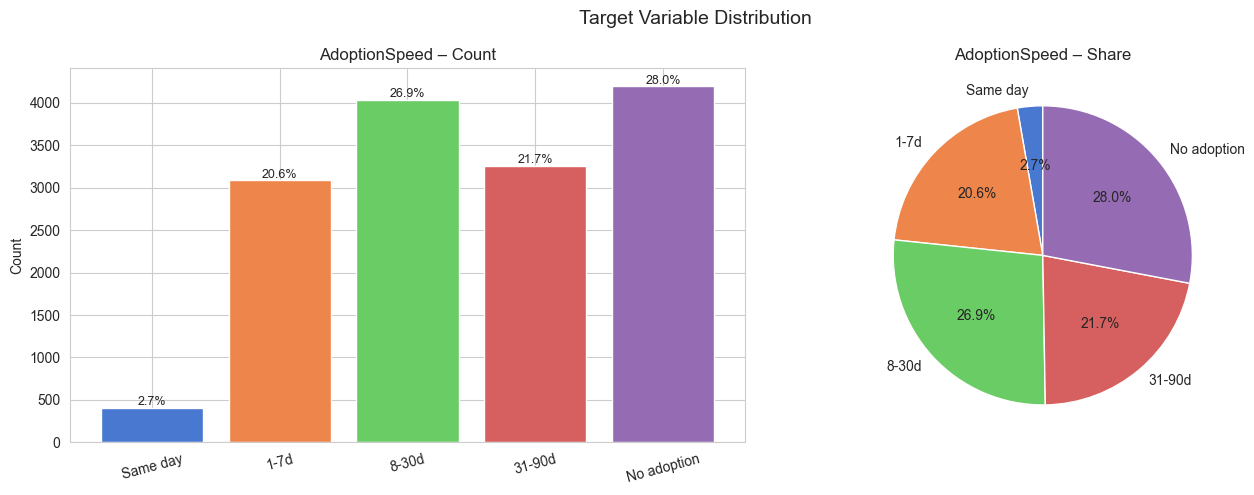

⚠️  Class imbalance note:
AdoptionSpeed
0     2.7
1    20.6
2    26.9
3    21.7
4    28.0
Name: % of dataset, dtype: float64


In [53]:
counts = df['AdoptionSpeed'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar([speed_labels[i] for i in counts.index],
                    counts.values, color=sns.color_palette('muted'))
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val/len(df)*100:.1f}%', ha='center', fontsize=9)
axes[0].set_title('AdoptionSpeed – Count', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(counts.values, labels=[speed_labels[i] for i in counts.index],
            autopct='%1.1f%%', colors=sns.color_palette('muted'), startangle=90)
axes[1].set_title('AdoptionSpeed – Share', fontsize=12)

plt.suptitle('Target Variable Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print('⚠️  Class imbalance note:')
print((counts / len(df) * 100).round(1).rename('% of dataset'))

## 4. Pet Characteristics
Physical traits: species, age, size, fur, color, gender.

C:\Users\norap\AppData\Local\Temp\ipykernel_34364\3521816501.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y='Age', data=df, ax=axes[0],


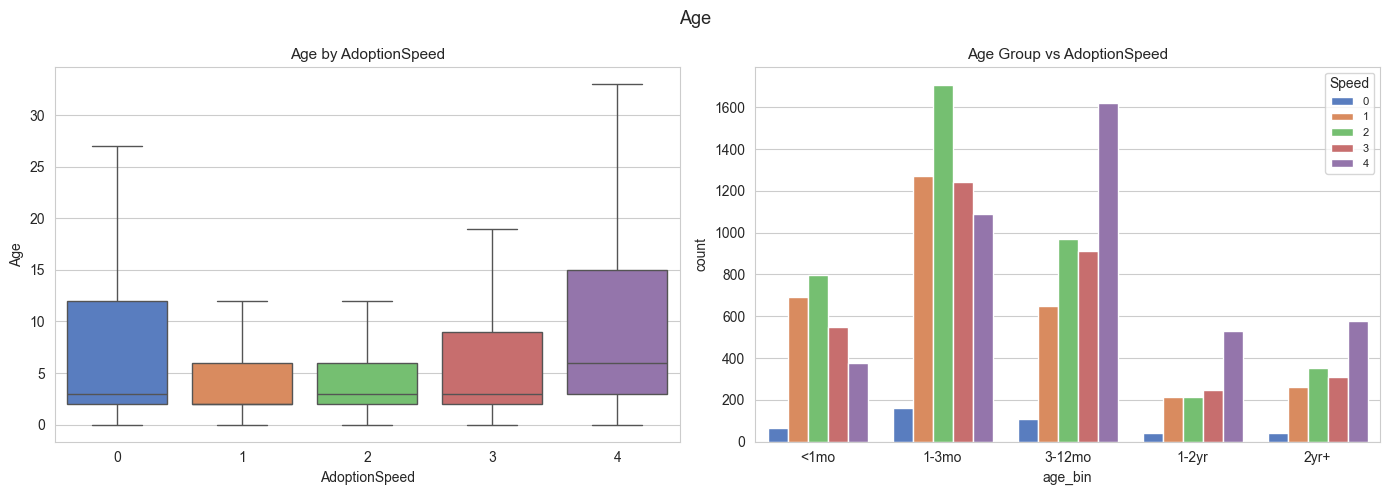

In [54]:
# --- Age ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='AdoptionSpeed', y='Age', data=df, ax=axes[0],
            palette='muted', showfliers=False)
axes[0].set_title('Age by AdoptionSpeed', fontsize=11)

sns.countplot(x='age_bin', hue='AdoptionSpeed', data=df, ax=axes[1],
              palette='muted', order=['<1mo','1-3mo','3-12mo','1-2yr','2yr+'])
axes[1].set_title('Age Group vs AdoptionSpeed', fontsize=11)
axes[1].legend(title='Speed', fontsize=8)

plt.suptitle('Age', fontsize=13)
plt.tight_layout()
plt.show()

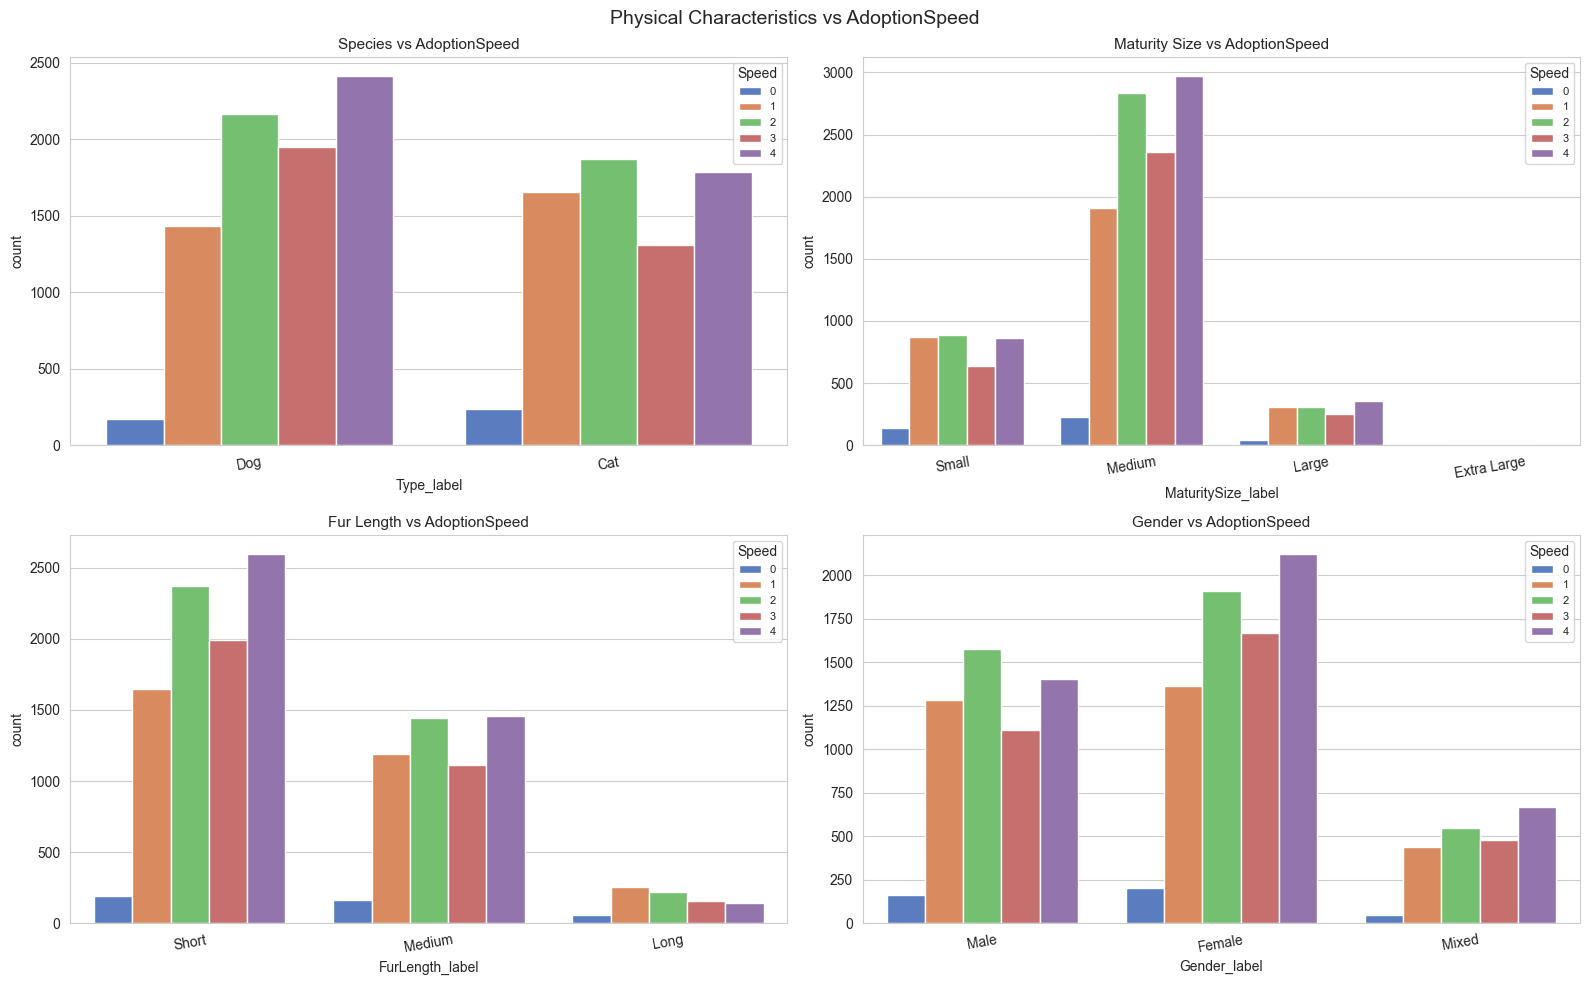

In [55]:
# --- Species, Size, Fur, Gender ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

plots = [
    ('Type_label',       ['Dog', 'Cat'],                          'Species'),
    ('MaturitySize_label',['Small','Medium','Large','Extra Large'],'Maturity Size'),
    ('FurLength_label',  ['Short','Medium','Long'],               'Fur Length'),
    ('Gender_label',     ['Male','Female','Mixed'],               'Gender'),
]

for i, (col, order, title) in enumerate(plots):
    sns.countplot(x=col, hue='AdoptionSpeed', data=df, ax=axes[i],
                  palette='muted', order=order)
    axes[i].set_title(title + ' vs AdoptionSpeed', fontsize=11)
    axes[i].legend(title='Speed', fontsize=8)
    axes[i].tick_params(axis='x', rotation=10)

plt.suptitle('Physical Characteristics vs AdoptionSpeed', fontsize=14)
plt.tight_layout()
plt.show()

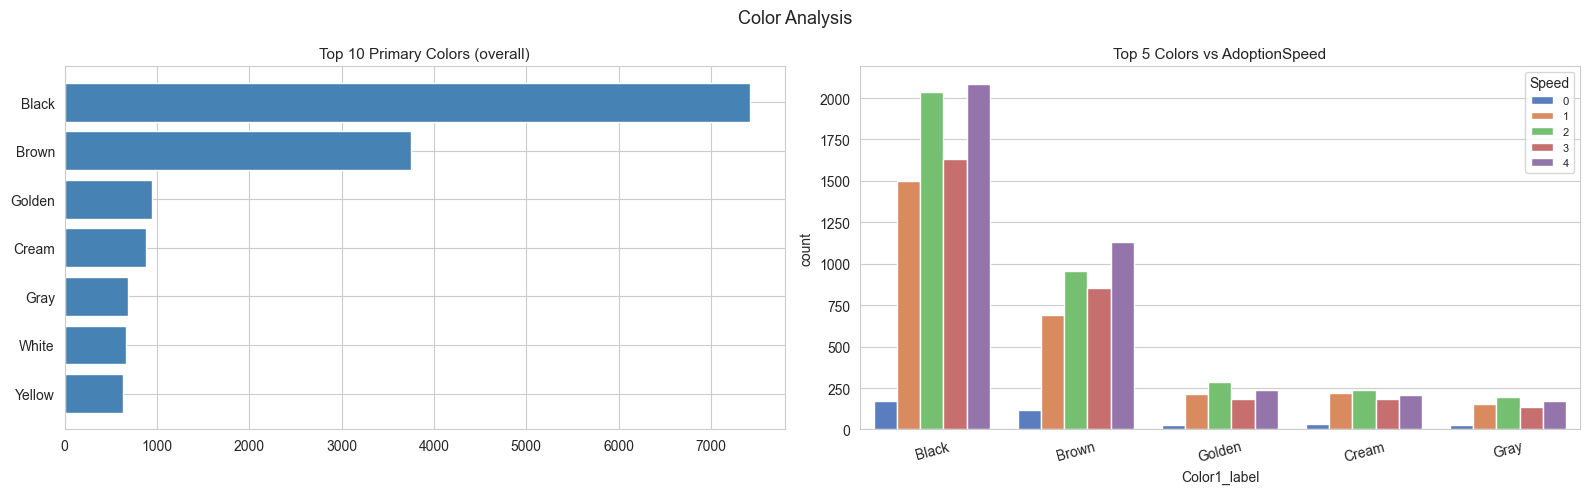

In [56]:
# --- Color ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_colors = df['Color1_label'].value_counts().head(10)
axes[0].barh(top_colors.index, top_colors.values, color='steelblue')
axes[0].set_title('Top 10 Primary Colors (overall)', fontsize=11)
axes[0].invert_yaxis()

top5 = df['Color1_label'].value_counts().head(5).index
sns.countplot(x='Color1_label', hue='AdoptionSpeed',
              data=df[df['Color1_label'].isin(top5)],
              ax=axes[1], palette='muted', order=top5)
axes[1].set_title('Top 5 Colors vs AdoptionSpeed', fontsize=11)
axes[1].legend(title='Speed', fontsize=8)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Color Analysis', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Health & Care Status
Vaccination, deworming, sterilization and overall health.

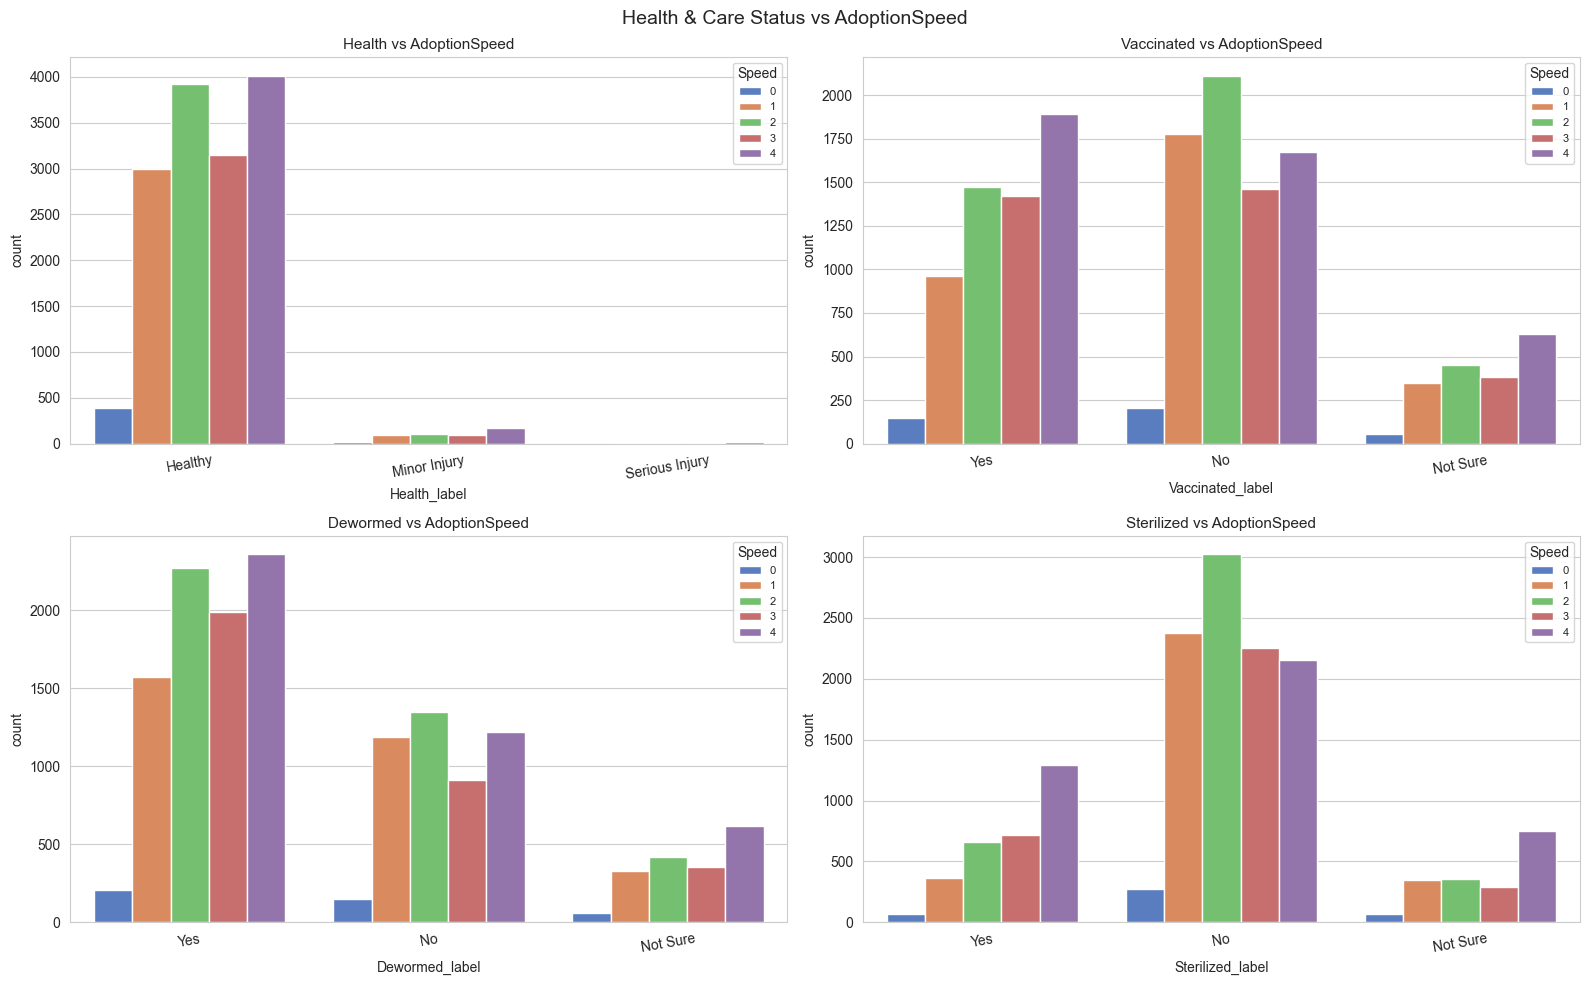

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

health_plots = [
    ('Health_label',     ['Healthy','Minor Injury','Serious Injury'], 'Health'),
    ('Vaccinated_label', ['Yes','No','Not Sure'],                     'Vaccinated'),
    ('Dewormed_label',   ['Yes','No','Not Sure'],                     'Dewormed'),
    ('Sterilized_label', ['Yes','No','Not Sure'],                     'Sterilized'),
]

for i, (col, order, title) in enumerate(health_plots):
    sns.countplot(x=col, hue='AdoptionSpeed', data=df, ax=axes[i],
                  palette='muted', order=order)
    axes[i].set_title(title + ' vs AdoptionSpeed', fontsize=11)
    axes[i].legend(title='Speed', fontsize=8)
    axes[i].tick_params(axis='x', rotation=10)

plt.suptitle('Health & Care Status vs AdoptionSpeed', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Listing Quality & Marketing
Photos, description, fee and name.

C:\Users\norap\AppData\Local\Temp\ipykernel_34364\338558559.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y='PhotoAmt', data=df, ax=axes[0],
C:\Users\norap\AppData\Local\Temp\ipykernel_34364\338558559.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  photo_speed = df.groupby(['photo_bin','AdoptionSpeed']).size().unstack(fill_value=0)


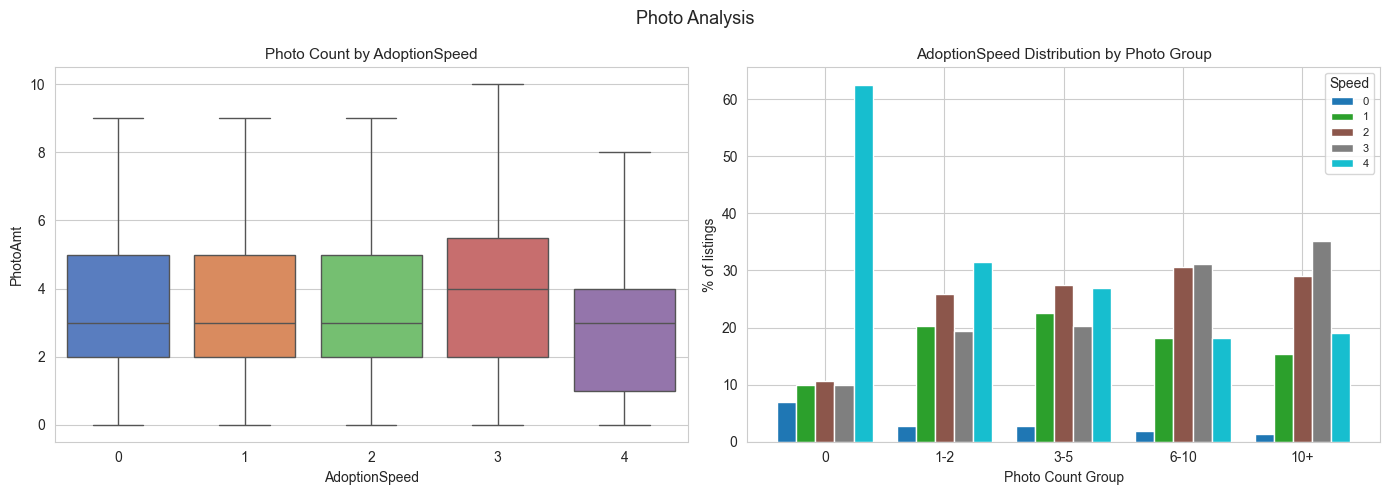

In [58]:
# --- Photo count ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='AdoptionSpeed', y='PhotoAmt', data=df, ax=axes[0],
            palette='muted', showfliers=False)
axes[0].set_title('Photo Count by AdoptionSpeed', fontsize=11)

photo_speed = df.groupby(['photo_bin','AdoptionSpeed']).size().unstack(fill_value=0)
photo_speed_pct = photo_speed.div(photo_speed.sum(axis=1), axis=0) * 100
photo_speed_pct.plot(kind='bar', ax=axes[1], colormap='tab10', width=0.8)
axes[1].set_title('AdoptionSpeed Distribution by Photo Group', fontsize=11)
axes[1].set_xlabel('Photo Count Group')
axes[1].set_ylabel('% of listings')
axes[1].legend(title='Speed', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Photo Analysis', fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\norap\AppData\Local\Temp\ipykernel_34364\2337981563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y='desc_word_count', data=df, ax=axes[0],
C:\Users\norap\AppData\Local\Temp\ipykernel_34364\2337981563.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_speed = df.groupby(['desc_bin','AdoptionSpeed']).size().unstack(fill_value=0)


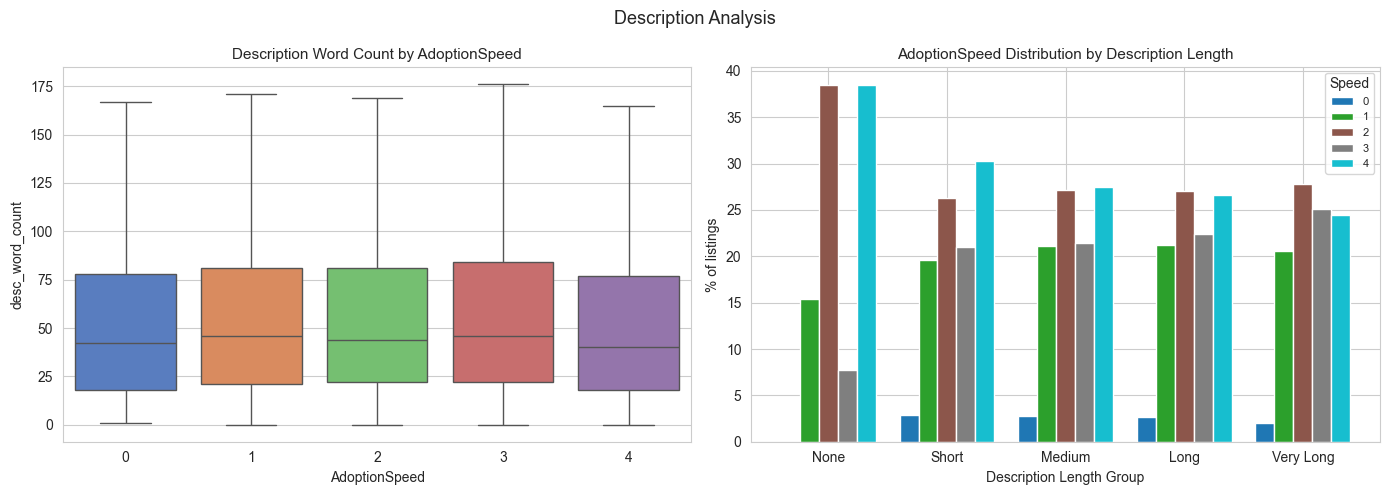

Missing descriptions: 13
Missing names: 1265


In [59]:
# --- Description length ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='AdoptionSpeed', y='desc_word_count', data=df, ax=axes[0],
            palette='muted', showfliers=False)
axes[0].set_title('Description Word Count by AdoptionSpeed', fontsize=11)

desc_speed = df.groupby(['desc_bin','AdoptionSpeed']).size().unstack(fill_value=0)
desc_speed_pct = desc_speed.div(desc_speed.sum(axis=1), axis=0) * 100
desc_speed_pct.plot(kind='bar', ax=axes[1], colormap='tab10', width=0.8)
axes[1].set_title('AdoptionSpeed Distribution by Description Length', fontsize=11)
axes[1].set_xlabel('Description Length Group')
axes[1].set_ylabel('% of listings')
axes[1].legend(title='Speed', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Description Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Missing descriptions: {df["Description"].isna().sum()}')
print(f'Missing names: {df["Name"].isna().sum()}')

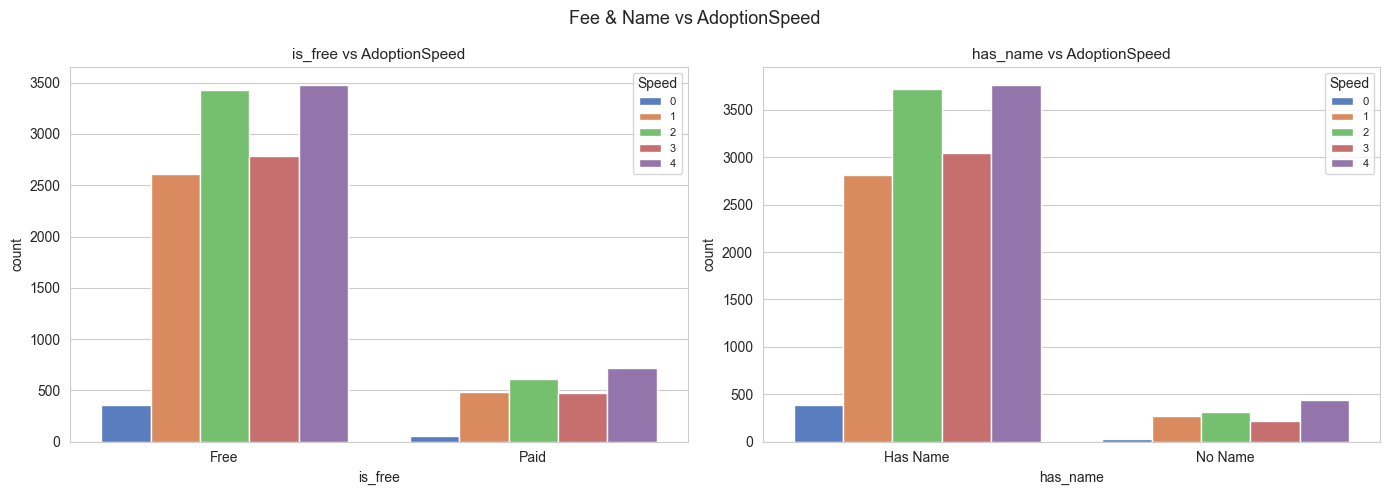

In [60]:
# --- Fee & Name ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['is_free', 'has_name']):
    order = df[col].value_counts().index
    sns.countplot(x=col, hue='AdoptionSpeed', data=df, ax=axes[i],
                  palette='muted', order=order)
    axes[i].set_title(col + ' vs AdoptionSpeed', fontsize=11)
    axes[i].legend(title='Speed', fontsize=8)

plt.suptitle('Fee & Name vs AdoptionSpeed', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Geography
Adoption patterns by Malaysian state.

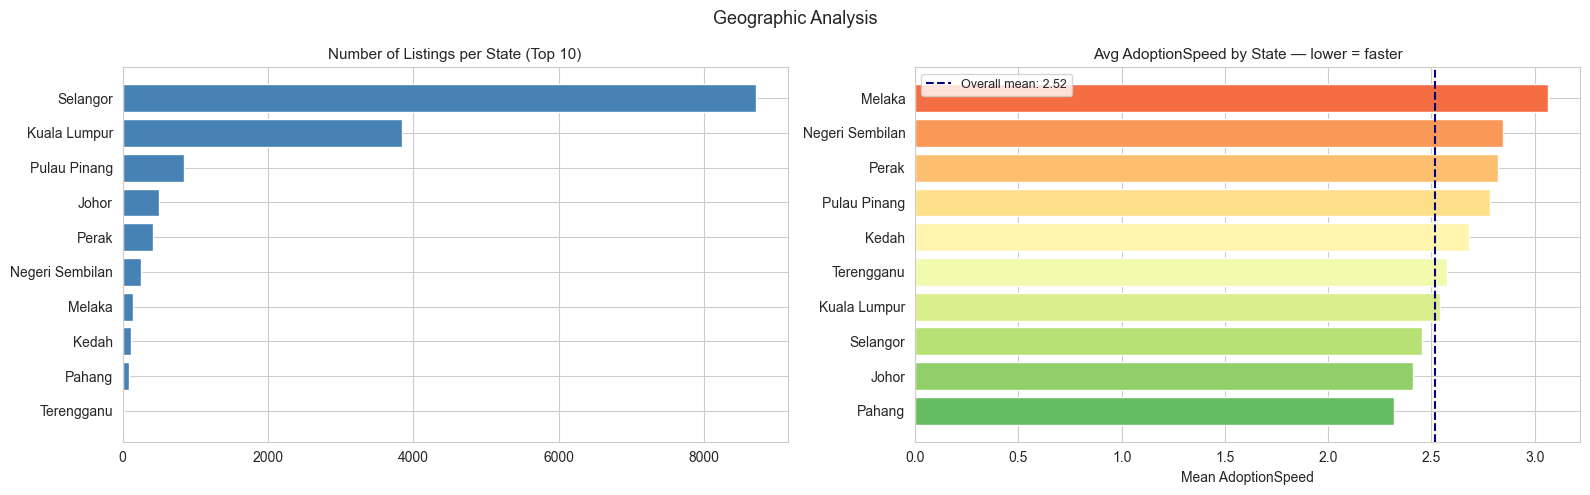

In [61]:
top10_states = df['State_label'].value_counts().head(10).index
df_states = df[df['State_label'].isin(top10_states)]
state_speed = df_states.groupby('State_label')['AdoptionSpeed'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Volume per state
state_counts = df['State_label'].value_counts().head(10)
axes[0].barh(state_counts.index, state_counts.values, color='steelblue')
axes[0].set_title('Number of Listings per State (Top 10)', fontsize=11)
axes[0].invert_yaxis()

# Avg adoption speed per state
axes[1].barh(state_speed.index, state_speed.values,
             color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(state_speed))))
axes[1].axvline(df['AdoptionSpeed'].mean(), color='navy', linestyle='--',
                label=f'Overall mean: {df["AdoptionSpeed"].mean():.2f}')
axes[1].set_title('Avg AdoptionSpeed by State — lower = faster', fontsize=11)
axes[1].set_xlabel('Mean AdoptionSpeed')
axes[1].legend(fontsize=9)

plt.suptitle('Geographic Analysis', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Correlation Summary

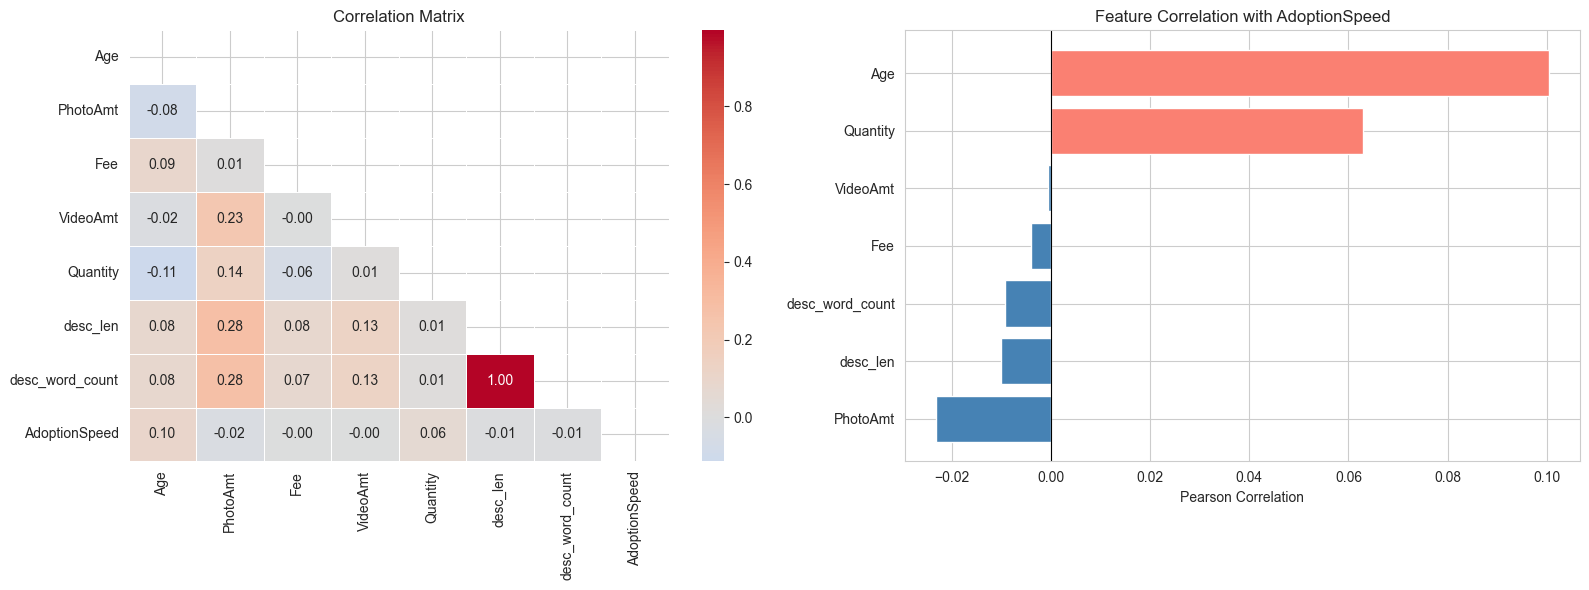

In [62]:
corr_cols = ['Age', 'PhotoAmt', 'Fee', 'VideoAmt', 'Quantity',
             'desc_len', 'desc_word_count', 'AdoptionSpeed']
corr = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Matrix', fontsize=12)

target_corr = corr['AdoptionSpeed'].drop('AdoptionSpeed').sort_values()
colors = ['salmon' if x > 0 else 'steelblue' for x in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with AdoptionSpeed', fontsize=12)
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

## 9. Key Takeaways

### Target
- Severe class imbalance: class 0 (same day) only 2.7%

### Pet Characteristics
- **Age** is the strongest numerical predictor: older pets adopt much slower; 1–3 month puppies/kittens adopt fastest
- **Color**: Black is by far the most common color and overrepresented in Speed 4 
- Species, size, fur length and gender show no strong standalone signal

### Health & Care
- Nearly all pets are listed as healthy → low discriminative power
- Pets listed as **not sterilized** dominate and show more Speed 4; sterilized pets slightly faster

### Listing Quality
- **No photo → 60%+ Speed 4**: strongest marketing signal in the dataset
- More photos help, but effect plateaus after 3–5
- Description length has no signal → sentiment content likely far more predictive
- Paid adoptions skew toward Speed 4; fee is a barrier

### Geography
- Selangor + KL account for ~85% of listings
- Pahang and Johor adopt faster than average; Melaka slowest (small sample caveat)

### Correlations
- All linear correlations < 0.10 → non-linear models (Random Forest, GBM) needed
- `desc_len` and `desc_word_count` are perfectly correlated → keep only one

### Missing Values
- Name: 8.4% missing → encode as binary `has_name`
- Description: 0.09% missing
